Exercice 1 : Détection et suppression des doublons

In [12]:

import pandas as pd
import requests as rq
import io
import zipfile as zf

# Charger le fichier train.csv depuis le ZIP
url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20&%20T/titanic%20dataset.zip"
response = rq.get(url)
read_zip = zf.ZipFile(io.BytesIO(response.content))
train = pd.read_csv(read_zip.open("titanic dataset/train.csv"))

# Détection et suppression des doublons
print(f"Nombre de lignes AVANT : {len(train)}")
print(f"Nombre de doublons trouvés : {train.duplicated().sum()}")
display(train[train.duplicated()])  # Afficher les doublons

train = train.drop_duplicates() #Suppression des doublons
print(f"Nombre de lignes APRÈS : {len(train)}")



Nombre de lignes AVANT : 891
Nombre de doublons trouvés : 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


Nombre de lignes APRÈS : 891


Exercice 2 : Gestion des valeurs manquantes

In [13]:
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
import requests as rq
import io
import zipfile as zf

# Charger le fichier train.csv depuis le ZIP
url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20&%20T/titanic%20dataset.zip"
response = rq.get(url)
read_zip = zf.ZipFile(io.BytesIO(response.content))
train = pd.read_csv(read_zip.open("titanic dataset/train.csv"))

# IDENTIFICATION DES VALEURS MANQUANTES
print(train.isnull().sum())

# STRATÉGIE 1 : SUPPRESSION — Embarked
train = train.dropna(subset=['Embarked']) 

print("\n Stratégie 1 - Suppression (Embarked) :")
print(f"Valeurs manquantes Embarked : {train['Embarked'].isnull().sum()}")

# STRATÉGIE 2 : IMPUTATION — Age
imputer = SimpleImputer(strategy='mean')
train['Age'] = imputer.fit_transform(train[['Age']])

print("\nStratégie 2 - Imputation par moyenne (Age) :")
print(f"Valeurs manquantes Age : {train['Age'].isnull().sum()}")
print(f"Moyenne utilisée : {train['Age'].mean():.1f} ans")

# STRATÉGIE 3 : VALEUR CONSTANTE — Cabin
train['Cabin'] = train['Cabin'].fillna('Unknown')

print("\nStratégie 3 - Valeur constante (Cabin) :")
print(f"Valeurs manquantes Cabin : {train['Cabin'].isnull().sum()}")

# VÉRIFICATION FINALE
print("Valeurs manquantes APRÈS traitement :")
print(train.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

 Stratégie 1 - Suppression (Embarked) :
Valeurs manquantes Embarked : 0

Stratégie 2 - Imputation par moyenne (Age) :
Valeurs manquantes Age : 0
Moyenne utilisée : 29.6 ans

Stratégie 3 - Valeur constante (Cabin) :
Valeurs manquantes Cabin : 0
Valeurs manquantes APRÈS traitement :
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


Exercice 3 : Ingénierie des fonctionnalités

In [14]:
from sklearn.preprocessing import LabelEncoder

# Création de la colonne FamilySize
# On additionne SibSp (frères/sœurs/conjoint) + Parch (parents/enfants) + 1 (la personne elle-même)
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1

print("Family Size créée :")
print(train[['SibSp', 'Parch', 'FamilySize']].head())


# Extraction du titre depuis la colonne Name
# Exemple : "Braund, Mr. Owen Harris" → "Mr"
train['Title'] = train['Name'].str.extract(r',\s*([^\.]+)\.')

print("Titres extraits :")
print(train['Title'].value_counts())

# On regroupe les titres rares sous "Other" pour simplifier
titres_communs = ['Mr', 'Miss', 'Mrs', 'Master']
train['Title'] = train['Title'].apply(
    lambda x: x if x in titres_communs else 'Other'
)

print("Titres après regroupement :")
print(train['Title'].value_counts())


# Label Encoding sur la colonne Title
# On convertit le texte en chiffres : Mr=0, Miss=1, Mrs=2, Master=3, Other=4
le = LabelEncoder()
train['Title_encoded'] = le.fit_transform(train['Title'])

print("Label Encoding sur Title :")
print(train[['Title', 'Title_encoded']].drop_duplicates().sort_values('Title_encoded'))


# One-Hot Encoding sur la colonne Embarked
# On transforme S, C, Q en 3 colonnes séparées avec des 0 et des 1
train = pd.get_dummies(train, columns=['Embarked'], prefix='Embarked')

print("One-Hot Encoding sur Embarked :")
print(train[['Embarked_S', 'Embarked_C', 'Embarked_Q']].head())


# Vérification finale des nouvelles colonnes créées
print(train[['FamilySize', 'Title', 'Title_encoded',
             'Embarked_S', 'Embarked_C', 'Embarked_Q']].head())

Family Size créée :
   SibSp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1
Titres extraits :
Title
Mr              517
Miss            181
Mrs             124
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64
Titres après regroupement :
Title
Mr        517
Miss      181
Mrs       124
Master     40
Other      27
Name: count, dtype: int64
Label Encoding sur Title :
     Title  Title_encoded
7   Master              0
2     Miss              1
0       Mr              2
1      Mrs              3
30   Other              4
One-Hot Encoding sur Embarked :
   Embarked_S  Embarked_C  Embarked_Q
0        True       False       False
1

Exercice 4 : Détection et traitement des valeurs aberrantes

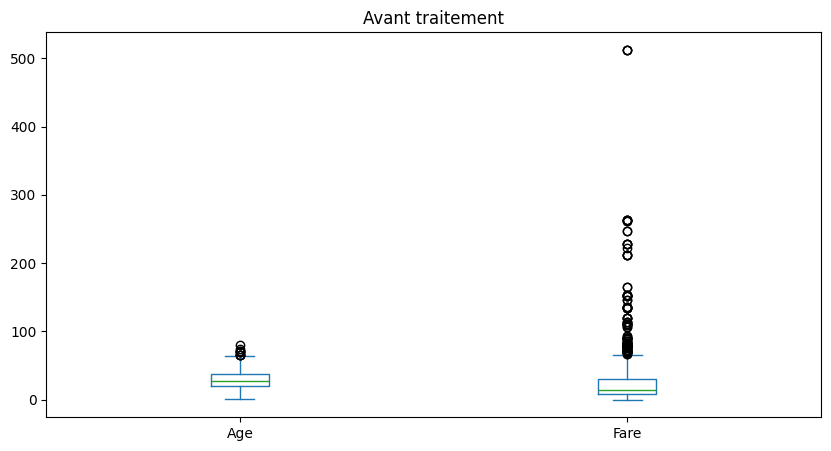

Aberrants Fare détectés : 116
Aberrants Fare Z-Score : 20
Lignes supprimées Age : 188


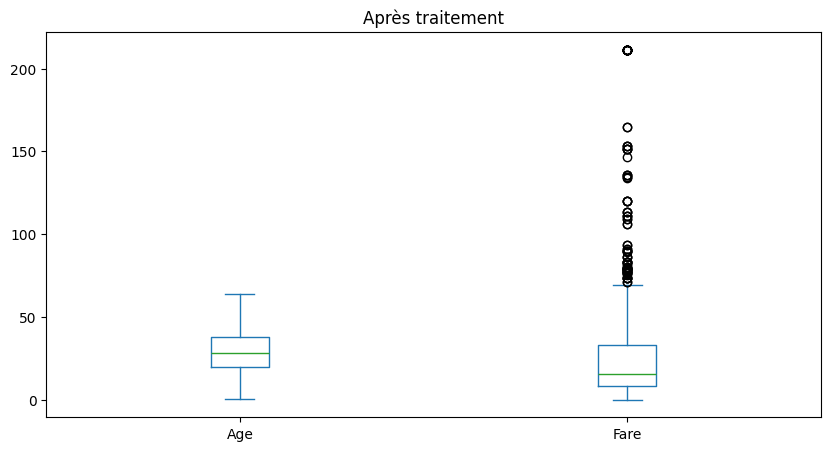

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import requests as rq
import io
import zipfile as zf
import pandas as pd

# Charger le fichier train.csv depuis le ZIP
url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20&%20T/titanic%20dataset.zip"
response = rq.get(url)
read_zip = zf.ZipFile(io.BytesIO(response.content))
train = pd.read_csv(read_zip.open("titanic dataset/train.csv"))


# visualisation AVANT traitement
train[['Age', 'Fare']].plot(kind='box', figsize=(10, 5))
plt.title('Avant traitement')
plt.show()

# détection avec IQR
Q1 = train['Fare'].quantile(0.25)
Q3 = train['Fare'].quantile(0.75)
IQR = Q3 - Q1
print(f"Aberrants Fare détectés : {((train['Fare'] < Q1 - 1.5*IQR) | (train['Fare'] > Q3 + 1.5*IQR)).sum()}")

# détection avec Z-Score
z_scores = np.abs(stats.zscore(train['Fare'].dropna()))
print(f"Aberrants Fare Z-Score : {(z_scores > 3).sum()}")

# traitement 1 : plafonnement au quantile 0.98
train['Fare'] = train['Fare'].clip(upper=train['Fare'].quantile(0.98))

# traitement 2 : transformation log
train['Fare_log'] = np.log1p(train['Fare'])

# traitement 3 : suppression des lignes aberrantes pour Age
Q1_age = train['Age'].quantile(0.25)
Q3_age = train['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
avant = len(train)
train = train[(train['Age'] >= Q1_age - 1.5*IQR_age) & (train['Age'] <= Q3_age + 1.5*IQR_age)]
print(f"Lignes supprimées Age : {avant - len(train)}")

# visualisation APRÈS traitement
train[['Age', 'Fare']].plot(kind='box', figsize=(10, 5))
plt.title('Après traitement')
plt.show()

Exercice 5 : Standardisation et normalisation des données

In [16]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# StandardScaler sur Age (distribution normale)
scaler = StandardScaler()
train['Age_scaled'] = scaler.fit_transform(train[['Age']])

# MinMaxScaler sur Fare (distribution asymétrique)
minmax = MinMaxScaler()
train['Fare_scaled'] = minmax.fit_transform(train[['Fare']])

# vérification des résultats
print("Age après StandardScaler :")
print(f"Moyenne : {train['Age_scaled'].mean():.2f}")
print(f"Ecart-type : {train['Age_scaled'].std():.2f}")

print("\nFare après MinMaxScaler :")
print(f"Min : {train['Fare_scaled'].min():.2f}")
print(f"Max : {train['Fare_scaled'].max():.2f}")

Age après StandardScaler :
Moyenne : 0.00
Ecart-type : 1.00

Fare après MinMaxScaler :
Min : 0.00
Max : 1.00


Exercice 6 : Encodage des caractéristiques

In [17]:
from sklearn.preprocessing import LabelEncoder

# correction du warning pandas
print("Colonnes catégorielles restantes :")
print(train.select_dtypes(include=['str']).columns.tolist())

# on crée Title s'il n'existe pas encore
if 'Title' not in train.columns:
    train['Title'] = train['Name'].str.extract(r',\s*([^\.]+)\.')
    titres_communs = ['Mr', 'Miss', 'Mrs', 'Master']
    train['Title'] = train['Title'].apply(
        lambda x: x if x in titres_communs else 'Other'
    )

# encodage one-hot sur Sex et Embarked
train = pd.get_dummies(train, columns=['Sex', 'Embarked'], prefix=['Sex', 'Embarked'])

# encodage label sur Title
le = LabelEncoder()
train['Title_encoded'] = le.fit_transform(train['Title'])

# vérification finale
print("\nAperçu des colonnes encodées :")
print(train[['Sex_male', 'Sex_female',
             'Embarked_S', 'Embarked_C', 'Embarked_Q',
             'Title_encoded']].head())

Colonnes catégorielles restantes :
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

Aperçu des colonnes encodées :
   Sex_male  Sex_female  Embarked_S  Embarked_C  Embarked_Q  Title_encoded
0      True       False        True       False       False              2
1     False        True       False        True       False              3
2     False        True        True       False       False              1
3     False        True        True       False       False              3
4      True       False        True       False       False              2


Exercice 7 : Transformation des données pour la caractéristique Âge

In [18]:
# création des groupes d'âge avec pd.cut()
# on définit les tranches : 0-12 = enfant, 12-18 = ado, 18-60 = adulte, 60-100 = senior
train['AgeGroup'] = pd.cut(
    train['Age'],
    bins=[0, 12, 18, 60, 100],
    labels=['Enfant', 'Adolescent', 'Adulte', 'Senior']
)

print("Répartition des groupes d'âge :")
print(train['AgeGroup'].value_counts())

# encodage one-hot sur AgeGroup
train = pd.get_dummies(train, columns=['AgeGroup'], prefix='Age')

# vérification
print("\nAperçu des colonnes créées :")
print(train[['Age_Enfant', 'Age_Adolescent', 'Age_Adulte', 'Age_Senior']].head(10))

Répartition des groupes d'âge :
AgeGroup
Adulte        553
Adolescent     70
Enfant         69
Senior         11
Name: count, dtype: int64

Aperçu des colonnes créées :
    Age_Enfant  Age_Adolescent  Age_Adulte  Age_Senior
0        False           False        True       False
1        False           False        True       False
2        False           False        True       False
3        False           False        True       False
4        False           False        True       False
6        False           False        True       False
7         True           False       False       False
8        False           False        True       False
9        False            True       False       False
10        True           False       False       False
